# 사이클 피처 23개 (v3) — 뭘 뺐고, 뭘 정규화했나

`Cycle_AE_v3.ipynb` 가 `Cycle_AE_v2.ipynb`(31피처, 정규화 없음) 대비 바꾼 두 가지를
**실제 데이터로 검증**하는 문서.

- 31개 피처 각각의 정의/계산 방식은 `Cycle_Features_설명서.ipynb` 참고 (여기서는 반복하지 않음)
- 여기서는 **v3가 뭘 다르게 했는지**만 본다: 8개 제거, 6개는 표준화 잔차로 교체 → 최종 23개
- 셀을 위에서부터 실행하면 최근 24시간 P1 데이터로 모든 숫자가 다시 계산된다

짝 노트북: `Cycle_AE_v3.ipynb`

In [1]:
import os, sys
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import extract_cycle_features, PUMP_MAP
from Cycle_Normalizer import ResidualNormalizer, NORMALIZE_SPECS, SUFFIX

PUMP_ID = "P1"
info = PUMP_MAP[PUMP_ID]
HEAD, ROBOT, SLOT = info["head"], info["robot"], info["slot"]

TAGS = [f"Pump_BuildUp_{PUMP_ID}", f"g_s_SV_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
        f"Scale_Out___PT_{PUMP_ID}", f"Ana_Out_{PUMP_ID}", f"TK_Temp_PV_{PUMP_ID}",
        f"Hz_Out_{PUMP_ID}", f"Shot_Injection_{HEAD}_P{SLOT}", f"{ROBOT}_Robot_Num",
        "AL_Line_Bit"] + [f"{HEAD}_FOAMING_SHOT{k}" for k in range(1, 7)]

ex = LogExtractor(env_path=os.path.join(ROOT_DIR, ".env"))
raw = ex.get_data(start_time="-24h", end_time="now()", target_tags=TAGS)
cyc, _ = extract_cycle_features(raw, PUMP_ID)
print(f"\n사이클 {len(cyc):,}개 추출 (원본 31피처 전부 계산됨)")

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-27T01:29:22.120531+00:00 ~ 2026-09-28T01:29:22.120548+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-27T01:19:22Z ~ 2026-09-27T07:19:22Z ... 

27901행
📦 [Chunk] 2026-09-27T07:19:22Z ~ 2026-09-27T13:19:22Z ... 

34387행
📦 [Chunk] 2026-09-27T13:19:22Z ~ 2026-09-27T19:19:22Z ... 

35112행
📦 [Chunk] 2026-09-27T19:19:22Z ~ 2026-09-28T01:19:22Z ... 

38326행
📦 [Chunk] 2026-09-28T01:19:22Z ~ 2026-09-28T01:29:22Z ... 

1091행
✅ 통합 완료 — 136603행 × 17컬럼


🌡️  온도 계열 컬럼 1개 — **단위가 태그마다 다르다.**
     TK_Temp_PV_P1            Scale_Max___TT_P1=1000 → 0.1℃ 단위, 값÷10
     ※ 2026-04 데이터는 Scale_Max___TT_P1=100 이었다. 지금은 1000 이라
       같은 태그가 22 → 228 로 찍힌다. 두 시기를 섞지 말 것.



사이클 556개 추출 (원본 31피처 전부 계산됨)


---
## 1. 뺀 8개 피처 — 상관관계로 확인

`Cycle_AE_v3.ipynb` 도입부가 근거로 든 상관계수를 이 세션의 데이터로 재현해본다.
수치는 추출 구간(최근 24시간)마다 달라지지만, **관계의 방향과 크기**는 그대로 나와야 한다.

| 뺀 피처 | 근거 |
|---|---|
| `Ana_Out_mean` | `SV_mean` 과 상관 ~1.0 (제어출력은 설정값의 함수라 정보가 안 늘어남) |
| `FT_max` | `SV_mean` / `FT_mean` 과 강한 상관 (안정구간에서 SV 근처로 수렴하니 당연) |
| `PT_max` | `PT_mean` 과 강한 상관 |
| `Ramp_Negative_Slope_Count` | 실제 이상 사례에서 범인으로 지목된 적이 거의 없음 |
| `Unexplained_PT_Dip_Count`/`_Max`, `Unexplained_FT_Dip_Count`/`_Max` | 유출 탐지는 이번 v3 모델 범위에서 제외하기로 함 (있으면 대부분 0) |

=== 상관관계로 뺀 3개 피처 (Ana_Out_mean, FT_max, PT_max) ===
  corr(Ana_Out_mean  , SV_mean   ) = +0.9993
  corr(FT_max        , SV_mean   ) = +0.9942
  corr(FT_max        , FT_mean   ) = +0.9841
  corr(PT_max        , PT_mean   ) = +0.9915


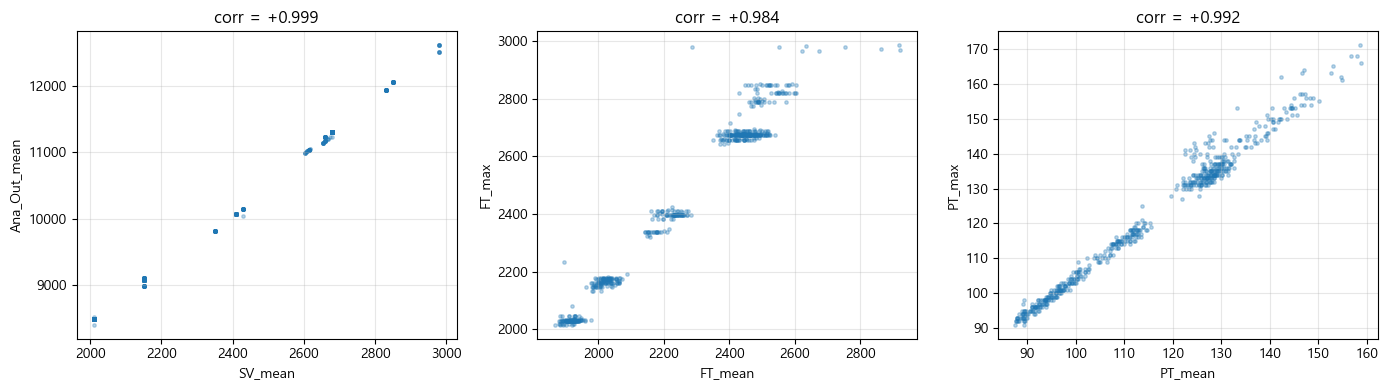

In [2]:
corr_pairs = [
    ("Ana_Out_mean", "SV_mean"),
    ("FT_max", "SV_mean"),
    ("FT_max", "FT_mean"),
    ("PT_max", "PT_mean"),
]
print("=== 상관관계로 뺀 3개 피처 (Ana_Out_mean, FT_max, PT_max) ===")
for a, b in corr_pairs:
    print(f"  corr({a:14s}, {b:10s}) = {cyc[a].corr(cyc[b]):+.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (a, b) in zip(axes, [("Ana_Out_mean", "SV_mean"), ("FT_max", "FT_mean"), ("PT_max", "PT_mean")]):
    ax.scatter(cyc[b], cyc[a], s=6, alpha=.3)
    ax.set_xlabel(b); ax.set_ylabel(a)
    ax.set_title(f"corr = {cyc[a].corr(cyc[b]):+.3f}")
    ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [3]:
event_cols = ["Ramp_Negative_Slope_Count", "Unexplained_PT_Dip_Count", "Unexplained_PT_Dip_Max",
              "Unexplained_FT_Dip_Count", "Unexplained_FT_Dip_Max"]
print("=== 이벤트성이라 뺀 5개 피처 — 대부분 0이라 모델이 배울 정보가 적다 ===")
print(f"{'피처':30s} {'0 아닌 비율':>12s} {'평균':>10s}")
for c in event_cols:
    nz = (cyc[c] > 0).mean() * 100
    print(f"{c:30s} {nz:11.1f}% {cyc[c].mean():10.4f}")

=== 이벤트성이라 뺀 5개 피처 — 대부분 0이라 모델이 배울 정보가 적다 ===
피처                                  0 아닌 비율         평균
Ramp_Negative_Slope_Count             14.0%     0.1978
Unexplained_PT_Dip_Count              30.4%     0.3831
Unexplained_PT_Dip_Max                30.4%     0.0146
Unexplained_FT_Dip_Count               2.2%     0.0234
Unexplained_FT_Dip_Max                 2.2%     0.0010


---
## 2. 정규화 6개 확인 — 표준화 잔차가 실제로 먹히는지

`Decay_Slope_PT` 같은 피처는 시작 조건(끄기 직전 압력 등)에 끌려다닌다는 게
`Cycle_Features_설명서.ipynb` 8절의 결론이었다. v3는 이 6개를 원본 대신
`ResidualNormalizer` 로 만든 `_z` 컬럼으로 바꿔 모델에 넣는다.

여기서는 그 변환을 이 세션 데이터에 그대로 적용해서, **기준변수와의 상관이 0 근처로
떨어지는지**만 확인한다. 왜 두 단계(위치+폭 보정)가 필요한지의 근거는 원본 설명서와
`Cycle_Normalizer.py` 상단 주석 참고.

In [4]:
# Cycle_AE_v3.ipynb 와 동일하게: 앞부분을 학습 구간으로 잡아 회귀를 적합하고
# 전체 구간에 그대로 적용한다 (Valid/Test 누수 방지와 같은 원리)
cutoff = cyc["Start_Time"].quantile(0.7)
train_mask = cyc["Start_Time"] < cutoff
print(f"학습 구간으로 사용: {train_mask.sum():,} / {len(cyc):,} 사이클 (앞 70%)")

norm = ResidualNormalizer()
norm.fit(cyc[train_mask])
cyc_n = norm.transform(cyc)

print("\n정규화 결과 — '원본 상관' 은 크고 '정규화 후 상관' 은 0 에 가까워야 성공\n")
print(norm.report(cyc_n).to_string(index=False))

학습 구간으로 사용: 389 / 556 사이클 (앞 70%)

정규화 결과 — '원본 상관' 은 크고 '정규화 후 상관' 은 0 에 가까워야 성공

              피처          기준변수  원본 상관  정규화 후 상관  정규화 후 평균  정규화 후 표준편차
  Decay_Slope_PT     PT_at_End -0.603    -0.012     0.027       0.969
  Decay_Slope_FT     FT_at_End -0.904    -0.015     0.027       1.024
FT_Jump_From_Pre PreBuildUp_FT -0.393     0.023    -0.093       2.008
    Cum_FT_Error       SV_mean  0.842     0.058     0.079       1.146
          FT_std       FT_mean  0.820     0.093    -0.015       1.137
 Current_Proxy_I       PT_mean  0.996    -0.017    -0.106       1.158


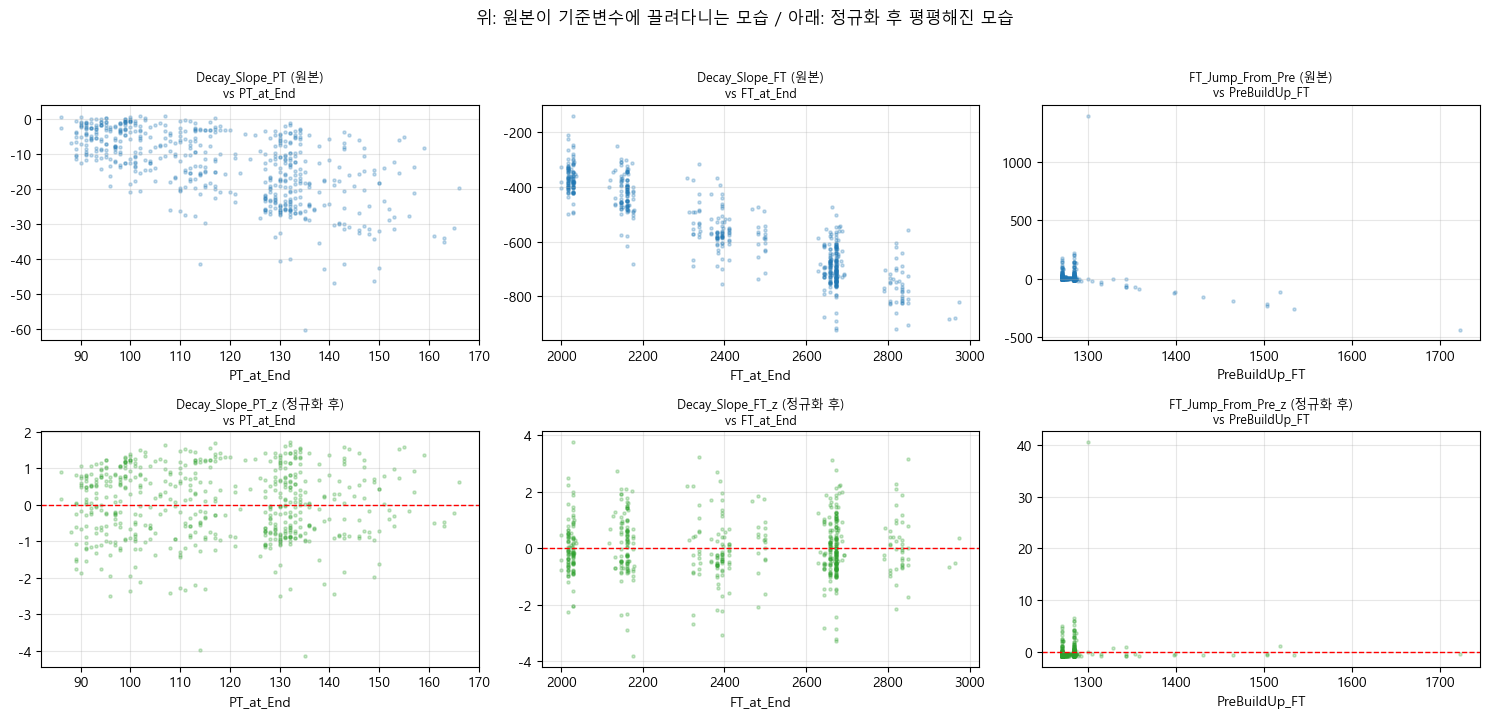

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
targets = list(NORMALIZE_SPECS.items())
for ax, (target, drivers) in zip(axes[0], targets[:3]):
    d = drivers[0]
    ax.scatter(cyc_n[d], cyc_n[target], s=5, alpha=.25, color="tab:blue")
    ax.set_title(f"{target} (원본)\nvs {d}", fontsize=9); ax.set_xlabel(d); ax.grid(alpha=.3)
for ax, (target, drivers) in zip(axes[1], targets[:3]):
    d = drivers[0]
    ax.scatter(cyc_n[d], cyc_n[target + SUFFIX], s=5, alpha=.25, color="tab:green")
    ax.axhline(0, color="red", ls="--", lw=1)
    ax.set_title(f"{target}{SUFFIX} (정규화 후)\nvs {d}", fontsize=9); ax.set_xlabel(d); ax.grid(alpha=.3)
fig.suptitle("위: 원본이 기준변수에 끌려다니는 모습 / 아래: 정규화 후 평평해진 모습", y=1.02)
plt.tight_layout(); plt.show()

---
## 3. 최종 모델 입력 23개

31개 전부는 계속 저장하지만(나중에 원인 분석용), 모델에는 아래 23개만 들어간다.

In [6]:
RAW_COLS = [
    "N_Ticks", "SV_mean", "FT_mean", "PT_mean", "PT_std", "Temp_mean",
    "Prev_SV", "Prev_SV_Diff", "PreBuildUp_PT", "PreBuildUp_FT", "PT_Jump_From_Pre",
    "Instant_FT_Error_Rate_mean", "Instant_FT_Error_Rate_max",
    "RampUp_Time_Sec", "DeltaP_over_Q", "Steady_Std_PT", "Steady_Std_FT",
]
NORM_COLS = [t + SUFFIX for t in NORMALIZE_SPECS]
FEATURE_COLS = RAW_COLS + NORM_COLS

print(f"모델 입력 {len(FEATURE_COLS)}개 = 원본 그대로 {len(RAW_COLS)}개 + 표준화 잔차 {len(NORM_COLS)}개\n")
print("원본 그대로:", RAW_COLS)
print("표준화 잔차:", NORM_COLS)

모델 입력 23개 = 원본 그대로 17개 + 표준화 잔차 6개

원본 그대로: ['N_Ticks', 'SV_mean', 'FT_mean', 'PT_mean', 'PT_std', 'Temp_mean', 'Prev_SV', 'Prev_SV_Diff', 'PreBuildUp_PT', 'PreBuildUp_FT', 'PT_Jump_From_Pre', 'Instant_FT_Error_Rate_mean', 'Instant_FT_Error_Rate_max', 'RampUp_Time_Sec', 'DeltaP_over_Q', 'Steady_Std_PT', 'Steady_Std_FT']
표준화 잔차: ['Decay_Slope_PT_z', 'Decay_Slope_FT_z', 'FT_Jump_From_Pre_z', 'Cum_FT_Error_z', 'FT_std_z', 'Current_Proxy_I_z']


In [7]:
summary = pd.DataFrame({
    "평균": cyc_n[FEATURE_COLS].mean(),
    "표준편차": cyc_n[FEATURE_COLS].std(),
    "최소": cyc_n[FEATURE_COLS].min(),
    "중앙값": cyc_n[FEATURE_COLS].median(),
    "최대": cyc_n[FEATURE_COLS].max(),
}).round(3)
print(f"모델 입력 {len(FEATURE_COLS)}개 분포")
print(summary.to_string())

모델 입력 23개 분포
                                  평균     표준편차        최소       중앙값        최대
N_Ticks                       16.050    3.029     4.000    16.000    54.000
SV_mean                     2425.154  296.032  2010.000  2430.000  2980.000
FT_mean                     2243.499  238.298  1866.333  2246.592  2922.167
PT_mean                      115.336   17.627    87.500   113.933   158.750
PT_std                         9.216    5.730     1.378     8.466    38.247
Temp_mean                    218.944   15.479   183.467   218.846   338.000
Prev_SV                     2429.083  319.444     0.000  2430.000  2980.000
Prev_SV_Diff                  -1.924  476.383  -820.000     0.000  2980.000
PreBuildUp_PT                 65.550    3.154    45.000    66.000    74.000
PreBuildUp_FT               1283.403   31.671  1271.000  1285.000  1723.000
PT_Jump_From_Pre              18.149   14.970    -5.000    18.000    66.000
Instant_FT_Error_Rate_mean     7.276    2.386     1.625     7.142    23.318

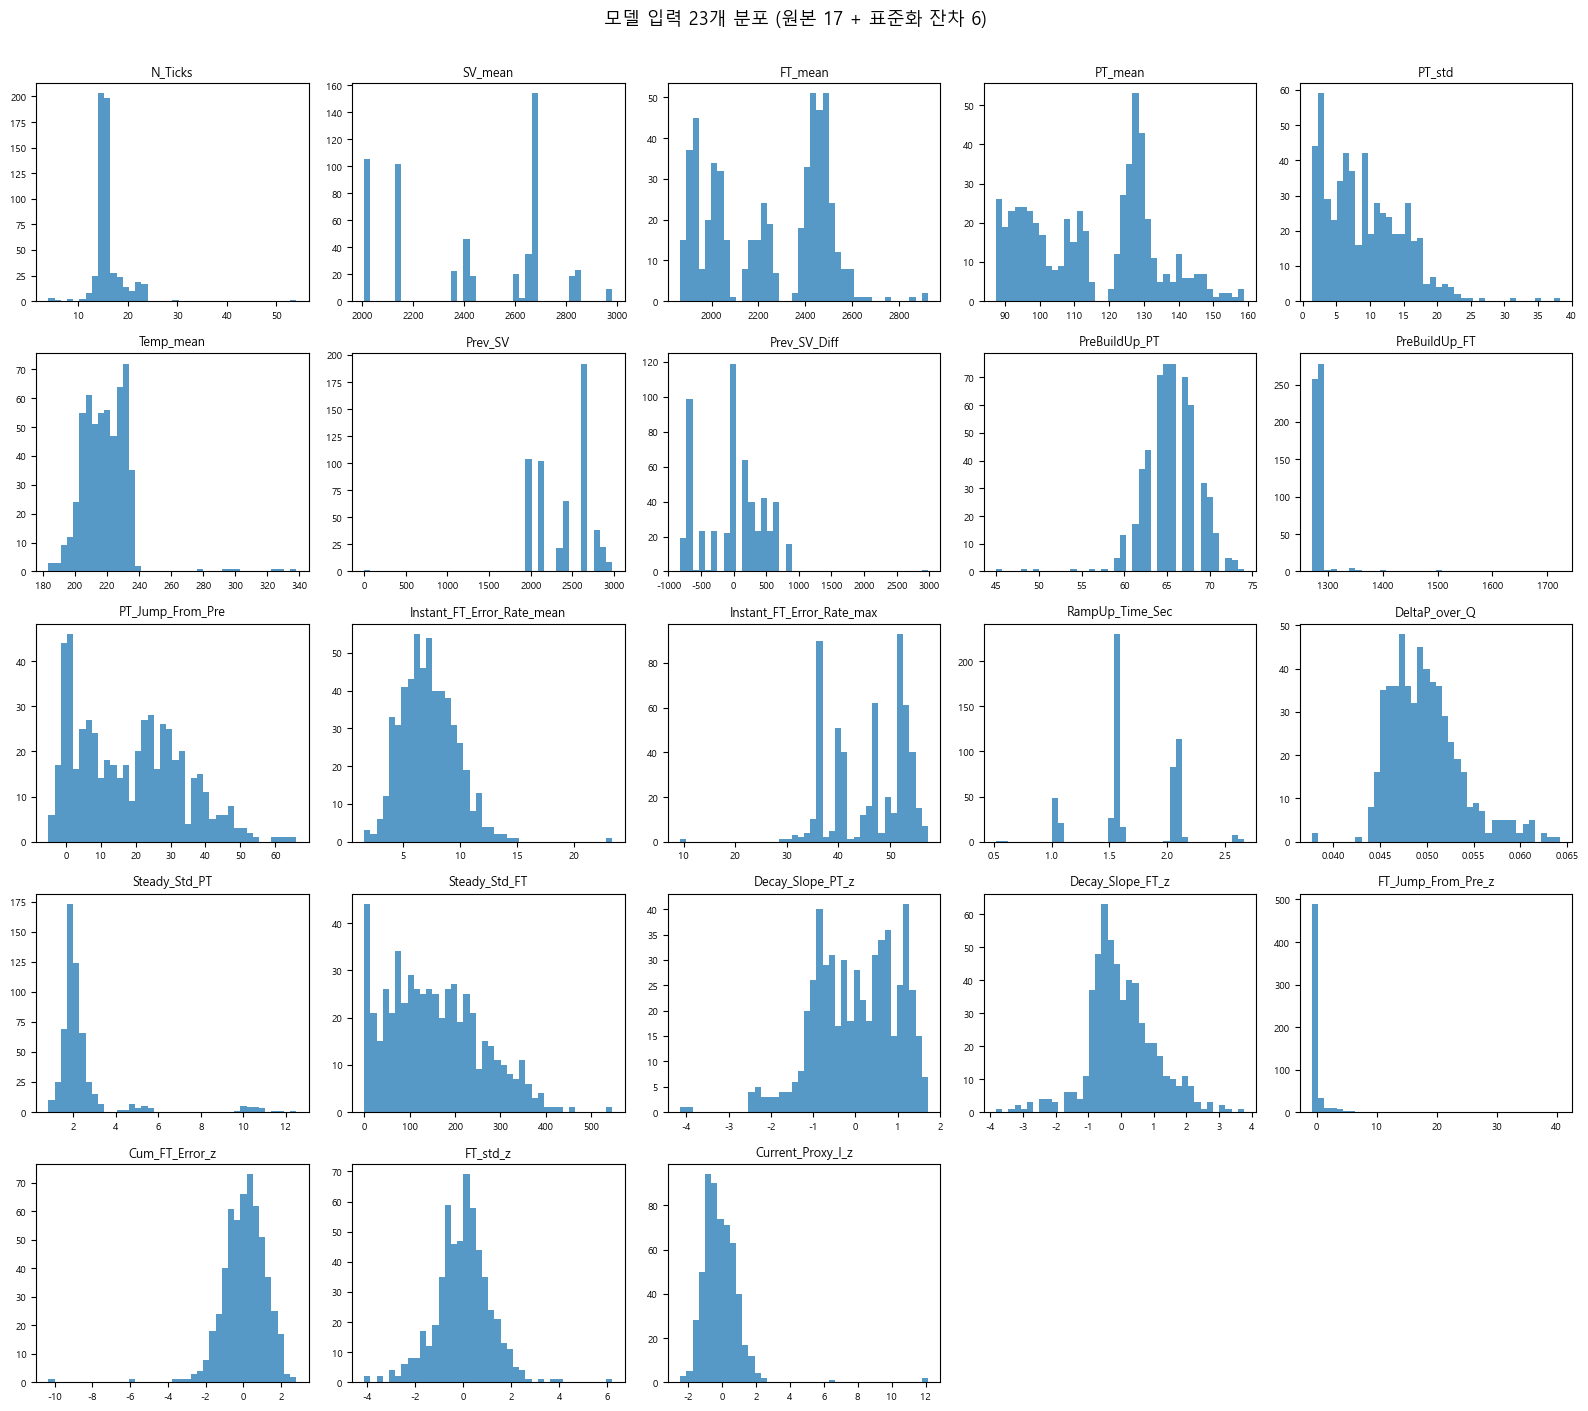

In [8]:
fig, axes = plt.subplots(5, 5, figsize=(16, 14))
for ax, c in zip(axes.ravel(), FEATURE_COLS):
    ax.hist(cyc_n[c].dropna(), bins=40, color="tab:blue", alpha=.75)
    ax.set_title(c, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(FEATURE_COLS):]:
    ax.axis("off")
fig.suptitle("모델 입력 23개 분포 (원본 17 + 표준화 잔차 6)", y=1.005, fontsize=13)
plt.tight_layout(); plt.show()

---
## 4. v2(31개) → v3(23개) 매핑

| 구분 | 개수 | 피처 |
|---|---|---|
| 그대로 유지 | 17 | `N_Ticks`, `SV_mean`, `FT_mean`, `PT_mean`, `PT_std`, `Temp_mean`, `Prev_SV`, `Prev_SV_Diff`, `PreBuildUp_PT`, `PreBuildUp_FT`, `PT_Jump_From_Pre`, `Instant_FT_Error_Rate_mean`, `Instant_FT_Error_Rate_max`, `RampUp_Time_Sec`, `DeltaP_over_Q`, `Steady_Std_PT`, `Steady_Std_FT` |
| 표준화 잔차로 교체 (`_z`) | 6 | `Decay_Slope_PT`, `Decay_Slope_FT`, `FT_Jump_From_Pre`, `Cum_FT_Error`, `FT_std`, `Current_Proxy_I` |
| 제거 | 8 | `Ana_Out_mean`, `FT_max`, `PT_max`, `Ramp_Negative_Slope_Count`, `Unexplained_PT_Dip_Count`, `Unexplained_PT_Dip_Max`, `Unexplained_FT_Dip_Count`, `Unexplained_FT_Dip_Max` |

**바뀌지 않은 것**: 사이클 정의(Pump_BuildUp on/off), 제외 규칙(야간 23:50~07:00 /
`AL_Line_Bit` / `Prev_SV==0`), 학습 방식(lr 5e-4 + ReduceLROnPlateau + Early Stopping),
임계치(Train 99퍼센타일). 자세한 내용은 `Cycle_Features_설명서.ipynb` 와
`Cycle_AE_v3.ipynb` 참고.